
# Hospital readmission risk 2026 (Riesgo de reingreso hospitalario _2026)

####Integrantes
- Cesar Daniel Ávila Barbosa
- Tatiana Lineros Sanchez
- Diego Mendoza Sarmiento

##Cargar librerias y conectar google colab

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats


#NUEVAS LIBRERIAS

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE   # si lo instalaste con pip install imbalanced-learn
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/PROYECTO_IA/hospital_readmission_risk_dataset_2026_v1_18000rows.csv')

Mounted at /content/drive


##Visualizacion del dataset y cambio de nombres a las variables

In [4]:
print('=== TIPOS DE VARIABLES ===')
df.info()

=== TIPOS DE VARIABLES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             18000 non-null  int64  
 1   Gender                          18000 non-null  object 
 2   Insurance_Type                  18000 non-null  object 
 3   Socioeconomic_Risk_Score        18000 non-null  int64  
 4   Previous_Admissions_6M          18000 non-null  int64  
 5   Previous_Readmissions_1Y        18000 non-null  int64  
 6   Time_Since_Last_Discharge       18000 non-null  int64  
 7   Length_of_Stay                  18000 non-null  int64  
 8   Admission_Type                  18000 non-null  object 
 9   Primary_Diagnosis_Group         18000 non-null  object 
 10  Comorbidity_Index               18000 non-null  int64  
 11  Chronic_Disease_Count           18000 non-null  int64  
 12  ICU_S

In [5]:
df = df.rename(columns={
"Age":"Edad",
"Gender":"Genero",
"Insurance_Type":"Tipo_Seguro",
"Socioeconomic_Risk_Score":"Riesgo_Socioeconomico",
"Previous_Admissions_6M":"Hospitalizaciones_6M",
"Previous_Readmissions_1Y":"Reingresos_1Año",
"Time_Since_Last_Discharge":"Tiempo_Ultima_Alta",
"Length_of_Stay":"Duracion_Estancia",
"Admission_Type":"Tipo_Admision",
"Primary_Diagnosis_Group":"Grupo_Diagnostico",
"Comorbidity_Index":"Indice_Comorbilidad",
"Chronic_Disease_Count":"Numero_Enfermedades_Cronicas",
"ICU_Stay_Flag":"Estuvo_UCI",
"Severity_Score":"Puntaje_Severidad",
"HbA1c_Level":"Nivel_HbA1c",
"Creatinine_Level":"Nivel_Creatinina",
"Hemoglobin_Level":"Nivel_Hemoglobina",
"Average_Systolic_BP":"Presion_Sistolica_Promedio",
"Number_of_Medications":"Numero_Medicamentos",
"Medication_Change_Count":"Cambios_Medicacion",
"High_Risk_Medication_Flag":"Medicacion_Alto_Riesgo",
"Followup_Appointment_Scheduled":"Cita_Control_Programada",
"Discharge_Disposition":"Condicion_Alta",
"Medication_Adherence_Score":"Adherencia_Medicacion",
"Readmitted_Within_30_Days":"Reingreso_30_Dias"
})

df.shape
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Edad                          18000 non-null  int64  
 1   Genero                        18000 non-null  object 
 2   Tipo_Seguro                   18000 non-null  object 
 3   Riesgo_Socioeconomico         18000 non-null  int64  
 4   Hospitalizaciones_6M          18000 non-null  int64  
 5   Reingresos_1Año               18000 non-null  int64  
 6   Tiempo_Ultima_Alta            18000 non-null  int64  
 7   Duracion_Estancia             18000 non-null  int64  
 8   Tipo_Admision                 18000 non-null  object 
 9   Grupo_Diagnostico             18000 non-null  object 
 10  Indice_Comorbilidad           18000 non-null  int64  
 11  Numero_Enfermedades_Cronicas  18000 non-null  int64  
 12  Estuvo_UCI                    18000 non-null  int64  
 13  P

In [6]:
print('\n=== ESTADÍSTICAS DESCRIPTIVAS ===')
df.describe().round(2)


=== ESTADÍSTICAS DESCRIPTIVAS ===


,Edad,Riesgo_Socioeconomico,Hospitalizaciones_6M,Reingresos_1Año,Tiempo_Ultima_Alta,Duracion_Estancia,Indice_Comorbilidad,Numero_Enfermedades_Cronicas,Estuvo_UCI,Puntaje_Severidad,Nivel_HbA1c,Nivel_Creatinina,Nivel_Hemoglobina,Presion_Sistolica_Promedio,Numero_Medicamentos,Cambios_Medicacion,Medicacion_Alto_Riesgo,Cita_Control_Programada,Adherencia_Medicacion,Reingreso_30_Dias
count,18000.00,18000.00,18000.00,18000.0,18000.00,18000.00,18000.00,18000.00,18000.0,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00,18000.00
mean,54.50,5.01,1.50,1.0,90.25,10.05,2.48,1.99,0.2,5.01,7.00,1.20,13.01,139.38,7.49,2.01,0.30,0.70,0.70,0.74
std,20.21,2.58,1.23,1.0,51.88,5.46,1.70,1.41,0.4,2.58,1.49,0.40,2.01,23.11,4.01,1.41,0.46,0.46,0.17,0.44
min,20.00,1.00,0.00,0.0,1.00,1.00,0.00,0.00,0.0,1.00,1.10,-0.42,5.49,100.00,1.00,0.00,0.00,0.00,0.40,0.00
25%,37.00,3.00,1.00,0.0,45.00,5.00,1.00,1.00,0.0,3.00,5.99,0.93,11.66,119.00,4.00,1.00,0.00,0.00,0.55,0.00
50%,54.00,5.00,1.00,1.0,91.00,10.00,2.00,2.00,0.0,5.00,7.02,1.20,13.00,140.00,7.00,2.00,0.00,1.00,0.70,1.00
75%,72.00,7.00,2.00,2.0,135.00,15.00,4.00,3.00,0.0,7.00,8.01,1.47,14.34,159.00,11.00,3.00,1.00,1.00,0.85,1.00
max,89.00,9.00,8.00,7.0,179.00,19.00,5.00,4.00,1.0,9.00,12.23,2.63,21.72,179.00,14.00,4.00,1.00,1.00,1.00,1.00


In [7]:
columnas_mostrar = [
    'Edad',
    'Genero',
    'Tipo_Seguro',
    'Duracion_Estancia',
    'Numero_Medicamentos',
    'Reingreso_30_Dias'
]

df[columnas_mostrar].head()

,Edad,Genero,Tipo_Seguro,Duracion_Estancia,Numero_Medicamentos,Reingreso_30_Dias
0,71,Male,Medicare,15,5,1
1,34,Female,Private,12,6,1
2,80,Male,Medicare,11,11,1
3,40,Female,Private,2,9,1
4,43,Male,Medicaid,3,6,0


## 1. Problema y Datos:

###**Problema**

En este trabajo se busca predecir si un paciente va a volver a ser hospitalizado dentro de los 30 días después de haber salido del hospital.

Este problema es importante porque cuando un paciente reingresa:

- Se generan más costos para el sistema de salud.

- Puede significar que el tratamiento no fue del todo efectivo.

- También puede afectar la salud y recuperación del paciente.

Por eso, poder anticipar estos casos ayudaría a tomar mejores decisiones y evitar reingresos innecesarios.

###**Datos**

El dataset que estamos usando fue tomado de Kaggle y contiene información sobre pacientes hospitalizados.

Este dataset tiene:

- 18,000 registros

- 25 variables

E incluye diferentes tipos de información sobre los pacientes, por ejemplo:

- Datos básicos: como la edad y el género.

- Información del hospital: tipo de admisión y duración de la estancia.

- Historial médico: hospitalizaciones en los últimos 6 meses y reingresos en el último año.

- Datos clínicos: niveles de creatinina, hemoglobina y presión arterial.

- Medicamentos: cantidad de medicamentos, cambios en la medicación y si son de alto riesgo.

Otros factores: como la adherencia a la medicación, condición al alta y si tiene cita de control.

## 2. Justificación de la IA:


- El uso de Inteligencia Artificial (IA) en la predicción de la readmisión hospitalaria a 30 días es altamente pertinente debido a la complejidad del problema y la naturaleza de los datos clínicos.
- En este contexto, la readmisión no depende de un único factor, sino de la interacción de múltiples variables como el historial clínico, la severidad del paciente, los tratamientos recibidos y su evolución médica. Estas relaciones suelen ser no lineales y difíciles de identificar mediante métodos estadísticos tradicionales.

La IA permite abordar este problema de manera efectiva gracias a los siguientes beneficios:
1. Identificación de patrones complejos:
- Aunque ninguna variable por sí sola está fuertemente relacionada con el reingreso, la IA puede detectar combinaciones complejas entre varias variables que sí aumentan el riesgo de que el paciente regrese al hospital.
2. Capacidad predictiva superior:
- Modelos como Random Forest o Gradient Boosting aprenden de los datos históricos y logran hacer predicciones más precisas sobre qué pacientes tienen mayor probabilidad de reingreso.
3. Aplicabilidad en entornos reales:
- El modelo puede integrarse en el sistema del hospital para identificar pacientes en riesgo antes de que sean dados de alta, permitiendo tomar acciones preventivas a tiempo.
4. Manejo de múltiples tipos de datos:
- La IA puede trabajar al mismo tiempo con información numérica (como edad o creatinina) y categórica (como tipo de seguro o grupo diagnóstico), sin complicar el análisis.
5. Optimización de recursos médicos:
- Al predecir quién tiene más riesgo de reingreso, se pueden priorizar los seguimientos, citas de control y recursos médicos en los pacientes que más los necesitan.

## 3. Variable Objetivo:

**Definición**

La variable que queremos predecir en este dataset es Reingreso_30_Dias.

Esta variable indica si un paciente vuelve a ser hospitalizado dentro de los 30 días después de haber sido dado de alta.

- Valor 1: el paciente sí fue reingresado

- Valor 0: el paciente no fue reingresado

Esta una variable categórica binaria, ya que solo tiene dos posibles valores (0 o 1).

**Análisis de la variable**

Para analizar esta variable se utilizará un gráfico de barras, ya que permite comparar fácilmente la cantidad de pacientes que fueron reingresados frente a los que no.

Además, anteriormente se calcularon las frecuencias y porcentajes de cada categoría:

- Reingreso (1): 74.16%

- No reingreso (0): 25.84%

Es importante observar que el dataset está desbalanceado, ya que hay muchos más casos de pacientes que sí reingresan que de los que no.

**Importancia**

Esta variable es la más importante del dataset, ya que:

- Es la que queremos predecir con el modelo.

- Permite identificar pacientes con alto riesgo de reingreso.

- Tiene impacto directo en decisiones médicas y administrativas.

,proportion
Reingreso_30_Dias,
1,0.741611
0,0.258389


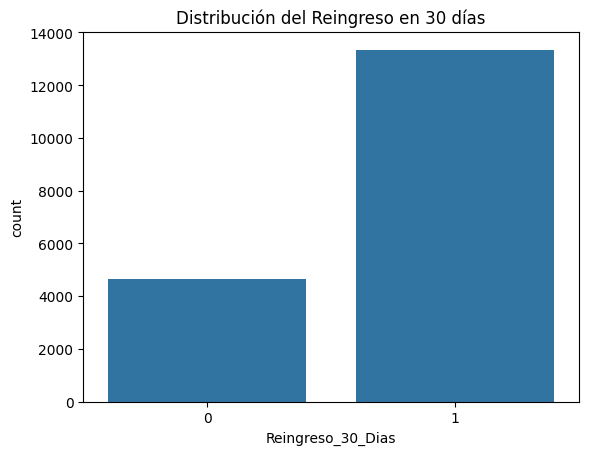

In [8]:
sns.countplot(data=df, x='Reingreso_30_Dias')
plt.title("Distribución del Reingreso en 30 días")

df['Reingreso_30_Dias'].value_counts()
df['Reingreso_30_Dias'].value_counts(normalize=True)

**Justificación del gráfico**

Se eligió un gráfico de barras porque:

- Es el más adecuado para variables categóricas.

- Permite comparar fácilmente las clases.

- Hace evidente el desbalance en los datos.

###Revisión y Limpieza de Datos

Antes de analizar, debemos garantizar que los datos son confiables.
Revisamos: **valores nulos**, **tipos de datos** y **outliers**.

In [9]:
# ── Valores nulos ──
nulos = df.isnull().sum()
print('=== VALORES NULOS POR COLUMNA ===')
df.isnull().sum()

=== VALORES NULOS POR COLUMNA ===


,0
Edad,0
Genero,0
Tipo_Seguro,0
Riesgo_Socioeconomico,0
Hospitalizaciones_6M,0
Reingresos_1Año,0
Tiempo_Ultima_Alta,0
Duracion_Estancia,0
Tipo_Admision,0
Grupo_Diagnostico,0


In [10]:
# ── Detección de Outliers — Método IQR ──
columnas_numericas = ['Edad','Puntaje_Severidad','Nivel_HbA1c','Nivel_Creatinina', 'Nivel_Hemoglobina',
                      'Hospitalizaciones_6M','Duracion_Estancia','Indice_Comorbilidad','Adherencia_Medicacion',
                      'Riesgo_Socioeconomico','Numero_Medicamentos']

resumen_outliers = []
for col in columnas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_out = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
    negativos = (df[col] < 0).sum()

    resumen_outliers.append({
        'Variable': col,
        'Min Real': round(df[col].min(), 3),
        'Max Real': round(df[col].max(), 3),
        'Outliers IQR': n_out,
        'Valores Negativos': negativos
    })

pd.DataFrame(resumen_outliers)

,Variable,Min Real,Max Real,Outliers IQR,Valores Negativos
0,Edad,20.00,89.00,0,0
1,Puntaje_Severidad,1.00,9.00,0,0
2,Nivel_HbA1c,1.10,12.23,126,0
3,Nivel_Creatinina,-0.42,2.63,130,31
4,Nivel_Hemoglobina,5.49,21.72,155,0
5,Hospitalizaciones_6M,0.00,8.00,1222,0
6,Duracion_Estancia,1.00,19.00,0,0
7,Indice_Comorbilidad,0.00,5.00,0,0
8,Adherencia_Medicacion,0.40,1.00,0,0
9,Riesgo_Socioeconomico,1.00,9.00,0,0


En la variable Nivel_Creatinina se detectaron 31 valores negativos (mínimo -0.42), lo cual es biológicamente imposible ya que la creatinina sérica nunca puede ser negativa en humanos.

In [11]:
# ── Corrección del outlier de Creatinine ──
mediana_creatinine = df['Nivel_Creatinina'].median()
df['Nivel_Creatinina'] = df['Nivel_Creatinina'].apply(
    lambda x: mediana_creatinine if x < 0 else x
)
print(f'Nuevo mínimo: {df["Nivel_Creatinina"].min():.3f}')

Nuevo mínimo: 0.010


Reemplazamos los valores atípicos (outliers) y los negativos de la creatinina por la mediana de la variable porque la mediana es un valor más estable y representativo del paciente típico, no se ve afectada por números extremos o errores, y así evitamos que esos datos raros distorsionen el análisis o el modelo de predicción de reingresos

## 4. Análisis de Distribuciones:

###Variables Categóricas

In [12]:
variables_categoricas = [
"Genero",
"Tipo_Seguro",
"Tipo_Admision",
"Grupo_Diagnostico",
"Estuvo_UCI",
"Medicacion_Alto_Riesgo",
"Cita_Control_Programada",
"Condicion_Alta",
"Reingreso_30_Dias"
]

EDA Categórico: Conteos, Porcentajes y Gráficos de Distribución


Variable: Genero
Frecuencia:
Genero
Male      9086
Female    8914
Name: count, dtype: int64

Porcentaje:
Genero
Male      50.48
Female    49.52
Name: proportion, dtype: float64


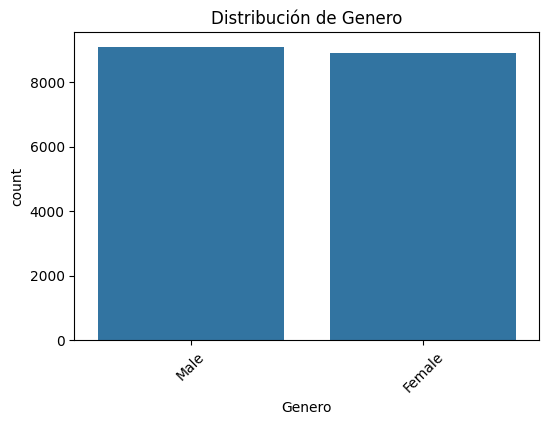

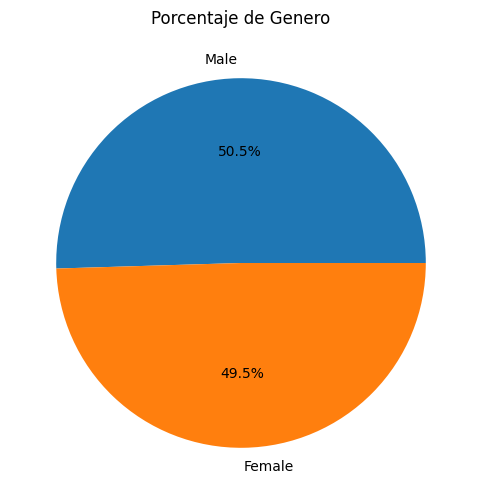


Variable: Tipo_Seguro
Frecuencia:
Tipo_Seguro
Medicare    6140
Medicaid    5999
Private     5861
Name: count, dtype: int64

Porcentaje:
Tipo_Seguro
Medicare    34.11
Medicaid    33.33
Private     32.56
Name: proportion, dtype: float64


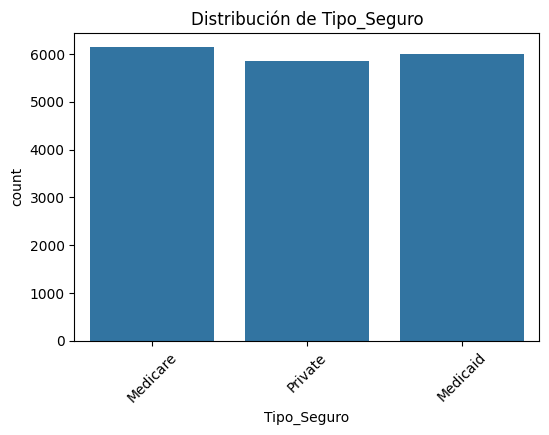

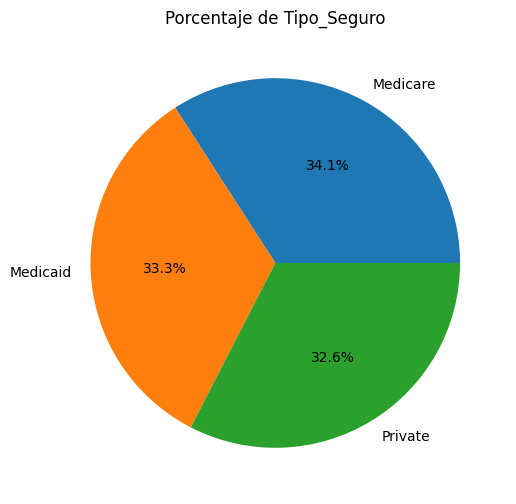


Variable: Tipo_Admision
Frecuencia:
Tipo_Admision
Urgent       6031
Emergency    5989
Elective     5980
Name: count, dtype: int64

Porcentaje:
Tipo_Admision
Urgent       33.51
Emergency    33.27
Elective     33.22
Name: proportion, dtype: float64


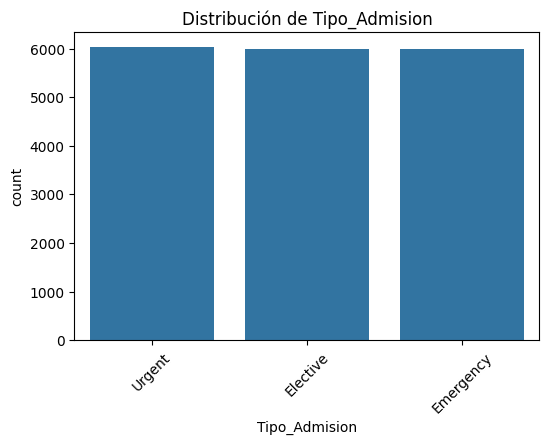

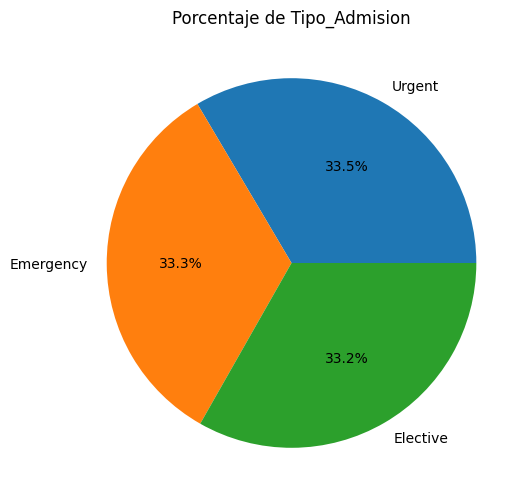


Variable: Grupo_Diagnostico
Frecuencia:
Grupo_Diagnostico
Other          3708
Infection      3615
Diabetes       3590
Respiratory    3551
Cardiac        3536
Name: count, dtype: int64

Porcentaje:
Grupo_Diagnostico
Other          20.60
Infection      20.08
Diabetes       19.94
Respiratory    19.73
Cardiac        19.64
Name: proportion, dtype: float64


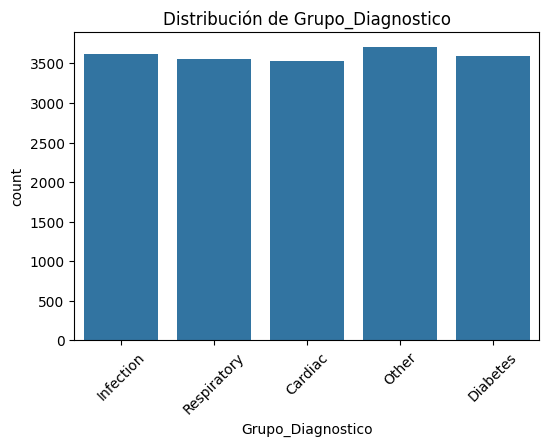

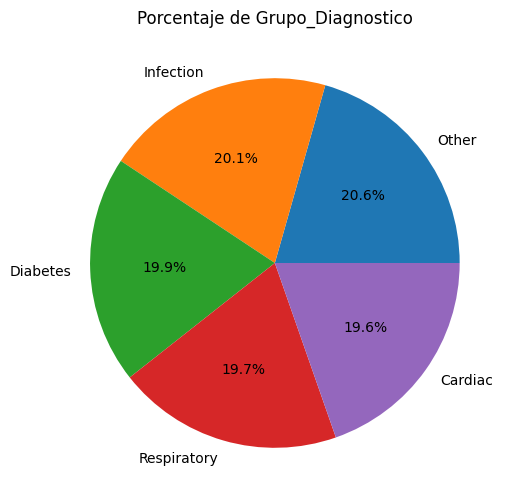


Variable: Estuvo_UCI
Frecuencia:
Estuvo_UCI
0    14440
1     3560
Name: count, dtype: int64

Porcentaje:
Estuvo_UCI
0    80.22
1    19.78
Name: proportion, dtype: float64


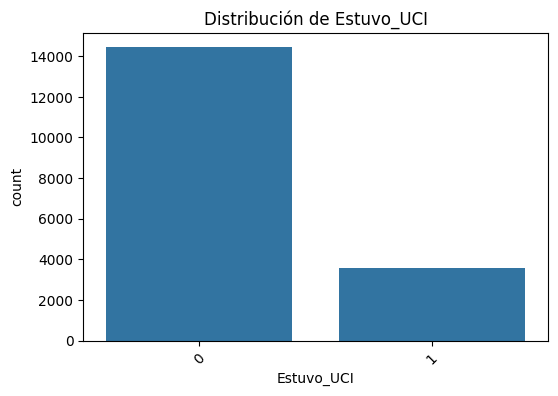

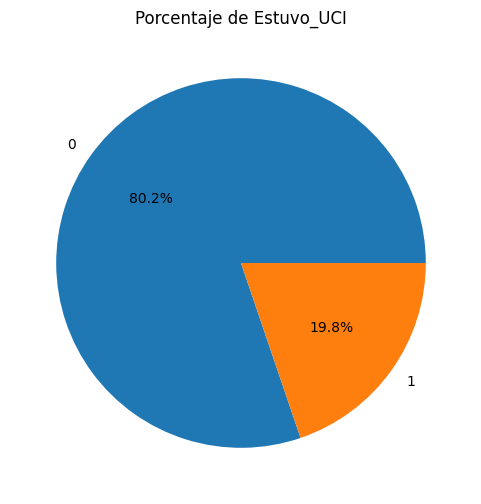


Variable: Medicacion_Alto_Riesgo
Frecuencia:
Medicacion_Alto_Riesgo
0    12560
1     5440
Name: count, dtype: int64

Porcentaje:
Medicacion_Alto_Riesgo
0    69.78
1    30.22
Name: proportion, dtype: float64


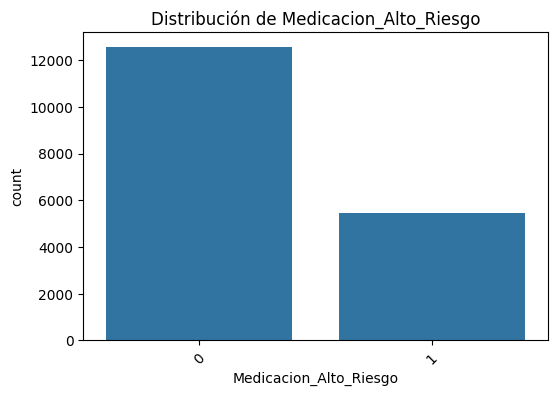

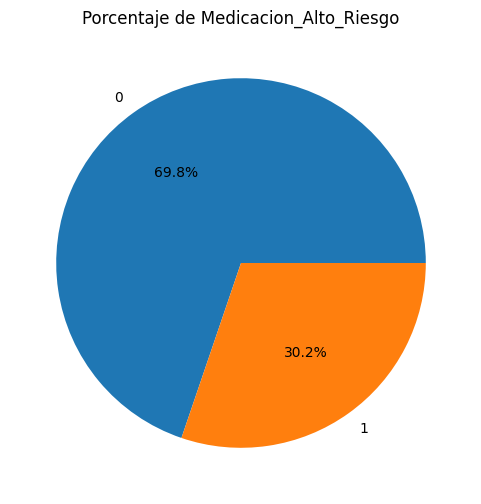


Variable: Cita_Control_Programada
Frecuencia:
Cita_Control_Programada
1    12588
0     5412
Name: count, dtype: int64

Porcentaje:
Cita_Control_Programada
1    69.93
0    30.07
Name: proportion, dtype: float64


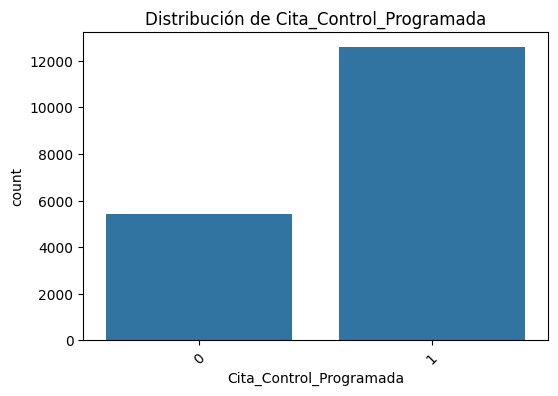

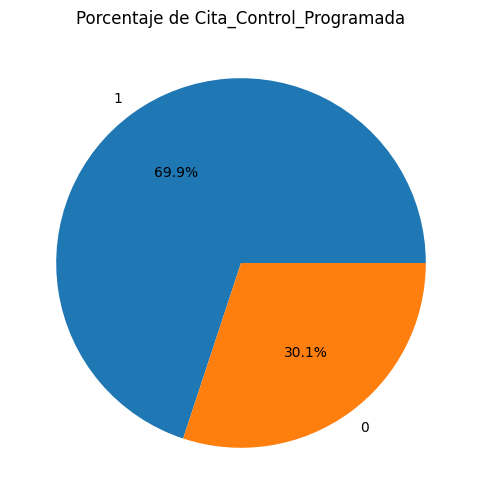


Variable: Condicion_Alta
Frecuencia:
Condicion_Alta
Home                6064
Nursing Facility    5990
Rehab               5946
Name: count, dtype: int64

Porcentaje:
Condicion_Alta
Home                33.69
Nursing Facility    33.28
Rehab               33.03
Name: proportion, dtype: float64


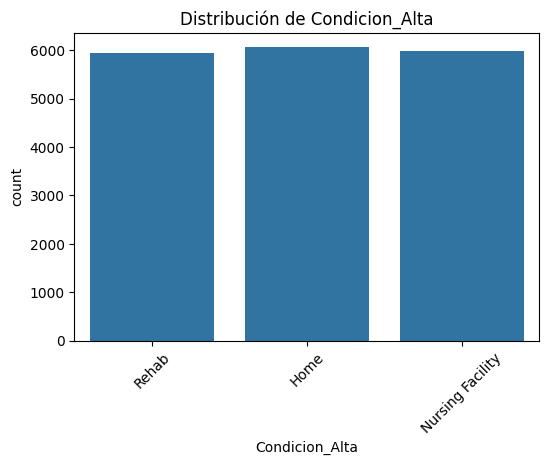

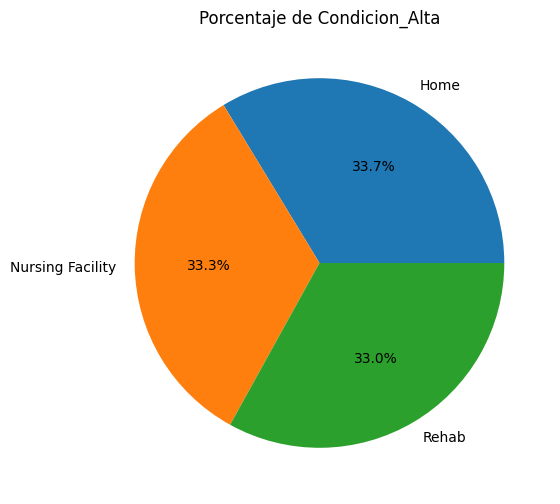


Variable: Reingreso_30_Dias
Frecuencia:
Reingreso_30_Dias
1    13349
0     4651
Name: count, dtype: int64

Porcentaje:
Reingreso_30_Dias
1    74.16
0    25.84
Name: proportion, dtype: float64


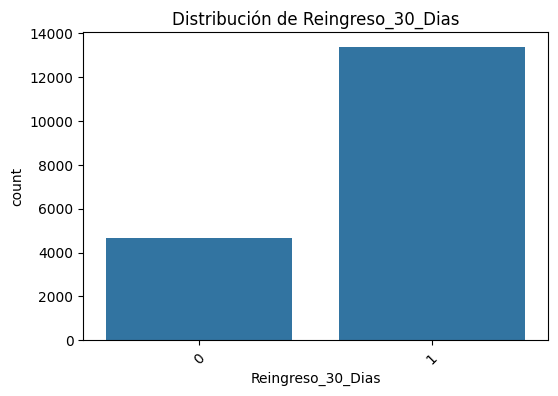

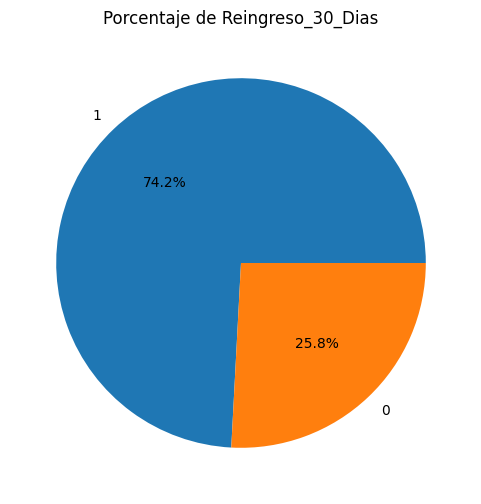

In [13]:
for col in variables_categoricas:

    conteo = df[col].value_counts()
    porcentaje = df[col].value_counts(normalize=True)*100

    print(f"\nVariable: {col}")
    print("Frecuencia:")
    print(conteo)

    print("\nPorcentaje:")
    print(porcentaje.round(2))

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(6,6))
    conteo.plot.pie(autopct="%1.1f%%")
    plt.title(f"Porcentaje de {col}")
    plt.ylabel("")
    plt.show()

####Género
- En este grupo de pacientes, hay casi la misma cantidad de hombres y mujeres. De un total aproximado de 18.000 personas, 9.086 son hombres (50.48%) y 8.914 son mujeres (49.52%). Es una distribución muy equilibrada, casi 50-50, lo que muestra que el hospital atiende por igual a ambos géneros.

####Tipo_Seguro
- El seguro de salud de los pacientes se reparte de manera muy pareja entre las tres opciones más comunes. El 34.11% (6.140 personas) tiene Medicare, el 33.33% (5.999) tiene Medicaid y el 32.56% (5.861) tiene seguro privado. Esto indica que en el hospital hay una mezcla bastante similar de pacientes con cobertura pública y privada.

####Tipo_Admision
- La forma como llegaron los pacientes al hospital está distribuida de forma casi idéntica entre las tres categorías. El 33.51% (6.031 casos) ingresó por urgencia programada, el 33.27% (5.989) por emergencia y el 33.22% (5.980) por ingreso electivo (es decir, programado con anticipación). Prácticamente un tercio para cada tipo.

####Grupo_Diagnostico
- Las principales razones por las que los pacientes fueron hospitalizados están muy equilibradas entre cinco grupos grandes. El más frecuente es “Other” con 20.60% (3.708 casos), seguido muy de cerca por infecciones (20.08%), diabetes (19.94%), problemas respiratorios (19.73%) y problemas cardíacos (19.64%). Esto muestra que no hay un solo tipo de enfermedad que domine claramente.

####Estuvo_UCI
- La gran mayoría de los pacientes, el 80.22% (14.440 personas), no necesitó estar en la Unidad de Cuidados Intensivos. Solo el 19.78% (3.560 personas) sí requirió cuidados intensivos. Esto nos dice que la mayoría de los casos fueron de gravedad moderada o baja, y solo una de cada cinco personas estuvo en estado crítico.

####Medicacion_Alto_Riesgo
- Más de dos tercios de los pacientes, el 69.78% (12.560 personas), no recibieron medicamentos considerados de alto riesgo durante su estancia. El 30.22% restante (5.440 personas) sí los recibió. Es decir, aproximadamente 3 de cada 10 pacientes usaron este tipo de medicinas que requieren mayor cuidado y seguimiento.

####Cita_Control_Programada
- Al ser dados de alta, el 69.93% de los pacientes (12.588 personas) recibió una cita de control programada para seguir revisando su salud después del hospital. El 30.07% (5.412 personas) no la recibió. Esto es positivo, ya que la mayoría sale con un plan de seguimiento médico.

####Condicion_Alta
- Cuando los pacientes fueron dados de alta, el destino fue muy similar en las tres opciones más comunes: el 33.69% (6.064 personas) regresó directamente a su casa, el 33.28% (5.990) fue a un centro de enfermería (Nursing Facility) y el 33.03% (5.946) a un centro de rehabilitación. Casi exactamente un tercio para cada destino.

####Reingreso_30_Dias
- Un porcentaje bastante alto de pacientes, el 74.16% (13.349 personas), volvió a ser hospitalizado dentro de los 30 días siguientes al alta. Solo el 25.84% (4.651 personas) no regresó en ese período. Esto indica que, en este grupo de datos, la mayoría de las personas tuvo que volver al hospital en menos de un mes.

###Variables númericas

In [14]:
variables_numericas = df.select_dtypes(include=np.number).columns
variables_numericas = [v for v in variables_numericas if v not in variables_categoricas]

####EDA Numérico:


Variable: Edad
coeficiente de asimetría: 0.00
Distribución aproximadamente SIMÉTRICA
Media: 54.50
Desviación estándar: 20.21


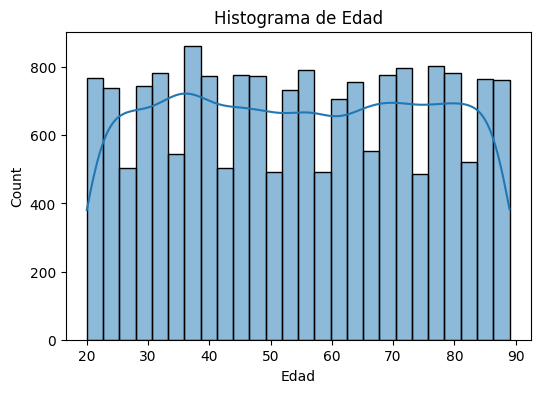


Variable: Riesgo_Socioeconomico
coeficiente de asimetría: 0.00
Distribución aproximadamente SIMÉTRICA
Media: 5.01
Desviación estándar: 2.58


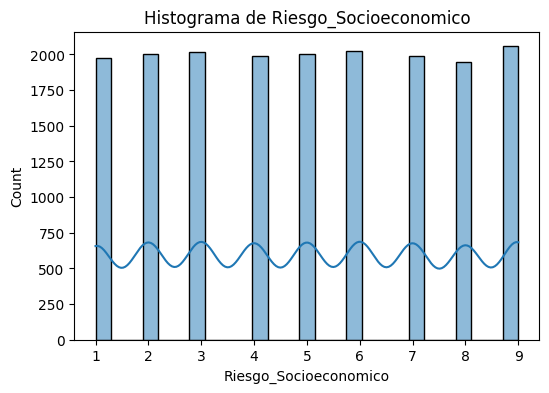


Variable: Hospitalizaciones_6M
coeficiente de asimetría: 0.80
Distribución ASIMÉTRICA
Mediana: 1.00
Min: 0.00
Max: 8.00
IQR: 1.00 - 2.00


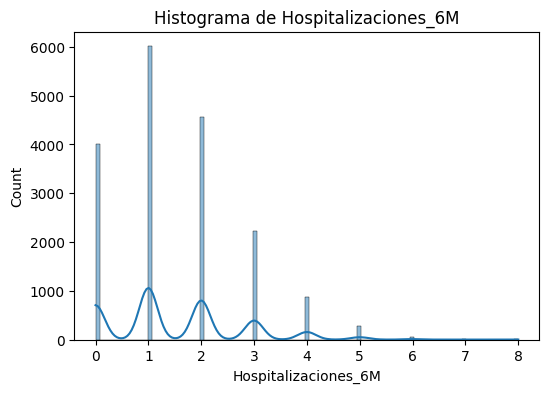

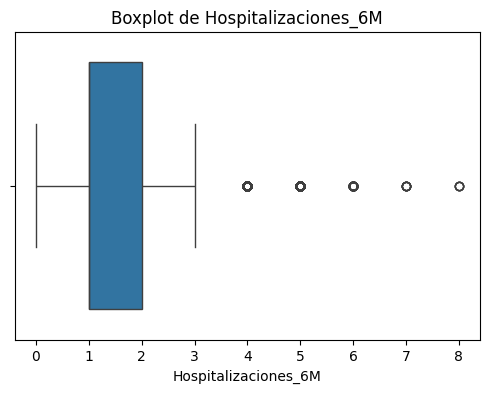


Variable: Reingresos_1Año
coeficiente de asimetría: 1.07
Distribución ASIMÉTRICA
Mediana: 1.00
Min: 0.00
Max: 7.00
IQR: 0.00 - 2.00


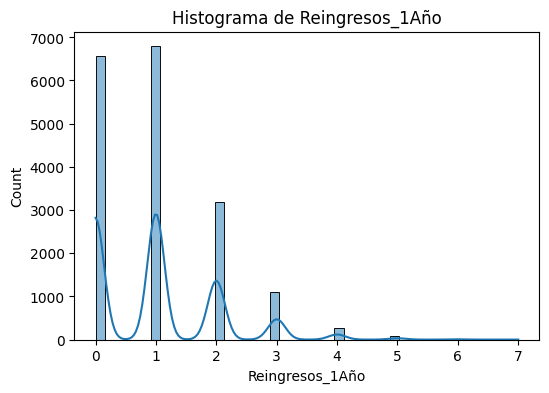

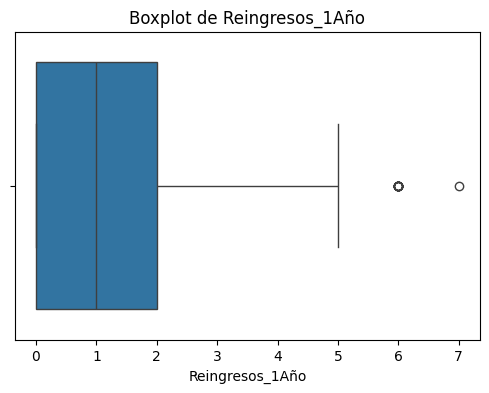


Variable: Tiempo_Ultima_Alta
coeficiente de asimetría: -0.01
Distribución aproximadamente SIMÉTRICA
Media: 90.25
Desviación estándar: 51.88


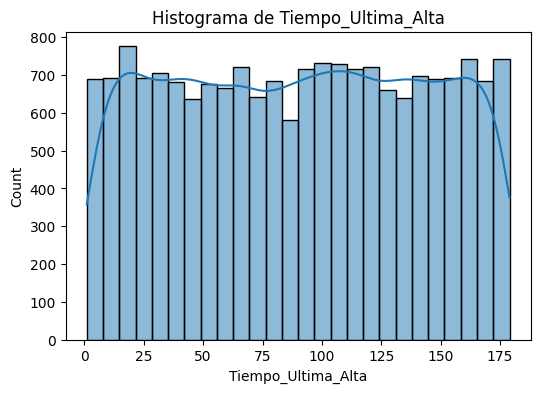


Variable: Duracion_Estancia
coeficiente de asimetría: -0.01
Distribución aproximadamente SIMÉTRICA
Media: 10.05
Desviación estándar: 5.46


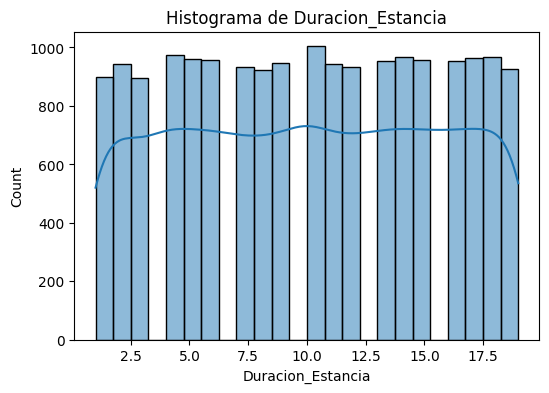


Variable: Indice_Comorbilidad
coeficiente de asimetría: 0.01
Distribución aproximadamente SIMÉTRICA
Media: 2.48
Desviación estándar: 1.70


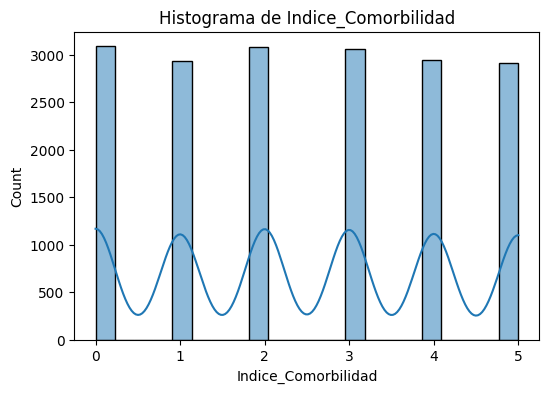


Variable: Numero_Enfermedades_Cronicas
coeficiente de asimetría: 0.01
Distribución aproximadamente SIMÉTRICA
Media: 1.99
Desviación estándar: 1.41


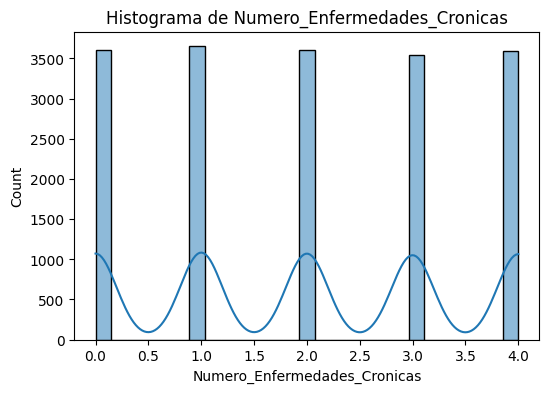


Variable: Puntaje_Severidad
coeficiente de asimetría: -0.00
Distribución aproximadamente SIMÉTRICA
Media: 5.01
Desviación estándar: 2.58


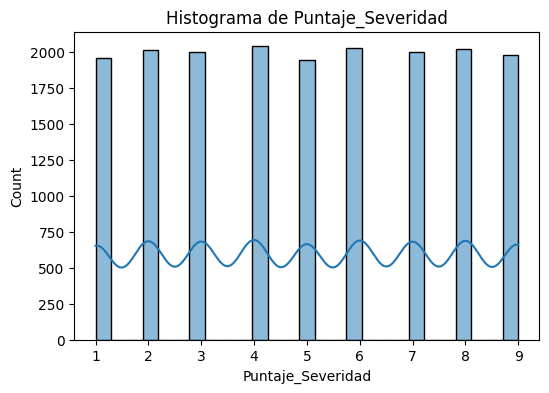


Variable: Nivel_HbA1c
coeficiente de asimetría: -0.02
Distribución aproximadamente SIMÉTRICA
Media: 7.00
Desviación estándar: 1.49


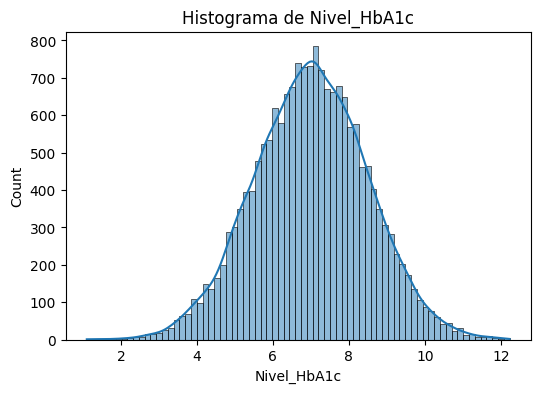


Variable: Nivel_Creatinina
coeficiente de asimetría: 0.01
Distribución aproximadamente SIMÉTRICA
Media: 1.20
Desviación estándar: 0.40


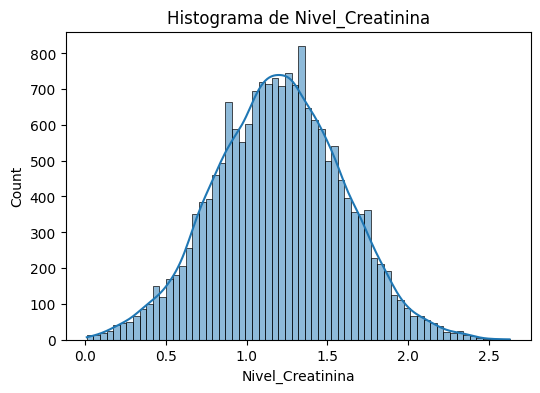


Variable: Nivel_Hemoglobina
coeficiente de asimetría: 0.02
Distribución aproximadamente SIMÉTRICA
Media: 13.01
Desviación estándar: 2.01


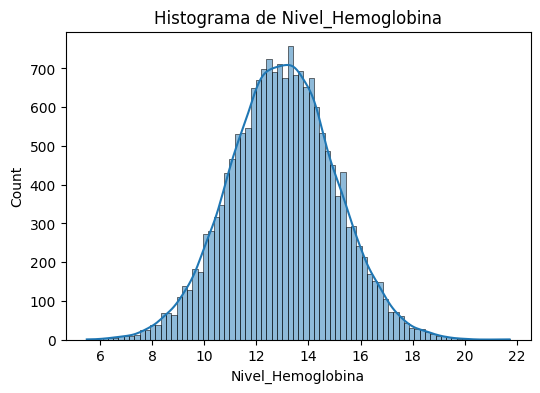


Variable: Presion_Sistolica_Promedio
coeficiente de asimetría: 0.00
Distribución aproximadamente SIMÉTRICA
Media: 139.38
Desviación estándar: 23.11


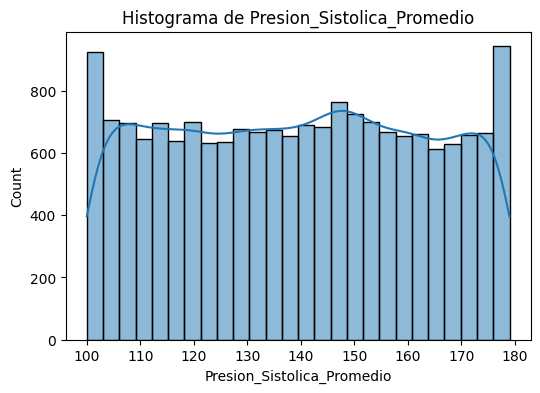


Variable: Numero_Medicamentos
coeficiente de asimetría: -0.00
Distribución aproximadamente SIMÉTRICA
Media: 7.49
Desviación estándar: 4.01


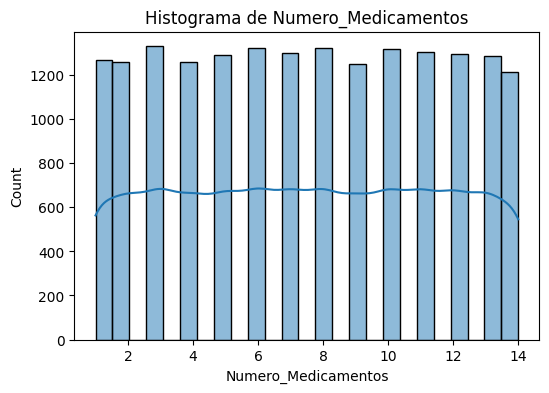


Variable: Cambios_Medicacion
coeficiente de asimetría: -0.00
Distribución aproximadamente SIMÉTRICA
Media: 2.01
Desviación estándar: 1.41


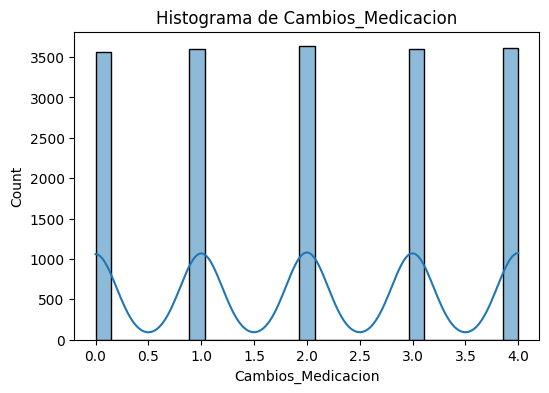


Variable: Adherencia_Medicacion
coeficiente de asimetría: -0.02
Distribución aproximadamente SIMÉTRICA
Media: 0.70
Desviación estándar: 0.17


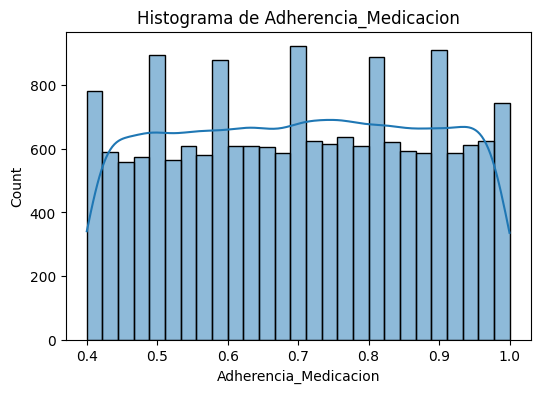

In [15]:
for col in variables_numericas:

    skew = df[col].skew()

    print(f"\nVariable: {col}")
    print(f"coeficiente de asimetría: {skew:.2f}")

    if abs(skew) < 0.5:

        print("Distribución aproximadamente SIMÉTRICA")

        media = df[col].mean()
        std = df[col].std()

        print(f"Media: {media:.2f}")
        print(f"Desviación estándar: {std:.2f}")

        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Histograma de {col}")
        plt.show()

    else:

        print("Distribución ASIMÉTRICA")

        mediana = df[col].median()
        minimo = df[col].min()
        maximo = df[col].max()
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)

        print(f"Mediana: {mediana:.2f}")
        print(f"Min: {minimo:.2f}")
        print(f"Max: {maximo:.2f}")
        print(f"IQR: {q1:.2f} - {q3:.2f}")

        plt.figure(figsize=(6,4))
        sns.histplot(df[col], kde=True)
        plt.title(f"Histograma de {col}")
        plt.show()

        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot de {col}")
        plt.show()

###Variables númericas simétricas

####Edad
- La edad promedio de los pacientes es de 54.5 ± 20.2 años. Esto significa que la mayoría tiene entre 34 y 75 años aproximadamente.

####Riesgo_Socioeconomico
- El nivel promedio de riesgo socioeconómico es de 5.01 ± 2.58 puntos. La mayoría de los pacientes se encuentra en un riesgo medio.


####Tiempo_Ultima_Alta
- El tiempo promedio desde la última alta es de 90.25 ± 51.88 días. La mayoría de los pacientes volvió al hospital entre 38 y 142 días después.


####Duracion_Estancia
- La duración promedio de la estancia hospitalaria es de 10.05 ± 5.46 días. La mayoría de los pacientes estuvo entre 4.6 y 15.5 días aproximadamente.

#### Indice_Comorbilidad
- El índice promedio de comorbilidades es de 2.48 ± 1.70 puntos. La mayoría de los pacientes tiene entre 0.8 y 4.2 enfermedades adicionales.

####Numero_Enfermedades_Cronicas
- El número promedio de enfermedades crónicas es de 1.99 ± 1.41. La mayoría de los pacientes tiene entre 0.6 y 3.4 enfermedades crónicas.

####Puntaje_Severidad
- El puntaje promedio de severidad es de 5.01 ± 2.58 puntos. La mayoría de los pacientes tiene una severidad media.

####Nivel_HbA1c
- El nivel promedio de HbA1c es de 7.00 ± 1.49. La mayoría de los pacientes está entre 5.5 y 8.5 aproximadamente.

####Nivel_Creatinina
- El nivel promedio de creatinina es de 1.20 ± 0.40 mg/dL. La mayoría de los pacientes tiene valores entre 0.8 y 1.6.

####Nivel_Hemoglobina
- El nivel promedio de hemoglobina es de 13.01 ± 2.01 g/dL. La mayoría de los pacientes está entre 11 y 15 aproximadamente.

####Presion_Sistolica_Promedio
- La presión sistólica promedio es de 139.38 ± 23.11 mmHg. La mayoría de los pacientes tiene entre 116 y 162 mmHg.

####Numero_Medicamentos
- El número promedio de medicamentos es de 7.49 ± 4.01. La mayoría de los pacientes recibe entre 3.5 y 11.5 medicamentos.

####Cambios_Medicacion
- El promedio de cambios en la medicación es de 2.01 ± 1.41. La mayoría de los pacientes tuvo entre 0.6 y 3.4 cambios.

####Adherencia_Medicacion
- El nivel promedio de adherencia a la medicación es de 0.70 ± 0.17 (70%). La mayoría de los pacientes tiene una adherencia entre 53% y 87%.

###Variables númericas asimétricas

####Hospitalizaciones_6M
- El histograma está inclinado hacia la derecha (más pacientes con pocos ingresos y unos pocos con muchos) y el boxplot muestra varios puntos fuera de la caja en los valores altos.
- Conclusión: La mediana de hospitalizaciones en los últimos 6 meses es de 1 (con rango intercuartil de 1 a 2). La mayoría de los pacientes tuvo entre 1 y 2 hospitalizaciones, pero algunos llegaron hasta 8.
####Reingresos_1Año
- El histograma está claramente inclinado hacia la derecha (muchos pacientes con 0 o 1 reingreso y muy pocos con 4 o más) y el boxplot tiene outliers alejados en los valores altos.
- Conclusión: La mediana de reingresos en el último año es de 1 (con rango intercuartil de 0 a 2). La mayoría tuvo entre 0 y 2 reingresos, pero algunos llegaron hasta 7.

# Boxplots:
Detección Visual de Outliers

Los boxplots muestran:

Caja central: rango intercuartílico (Q1 a Q3) — donde se concentra el 50% central de los datos
Línea interior: Mediana (Q2)
Bigotes: valores dentro de 1.5×IQR
Puntos externos: Outliers potenciales

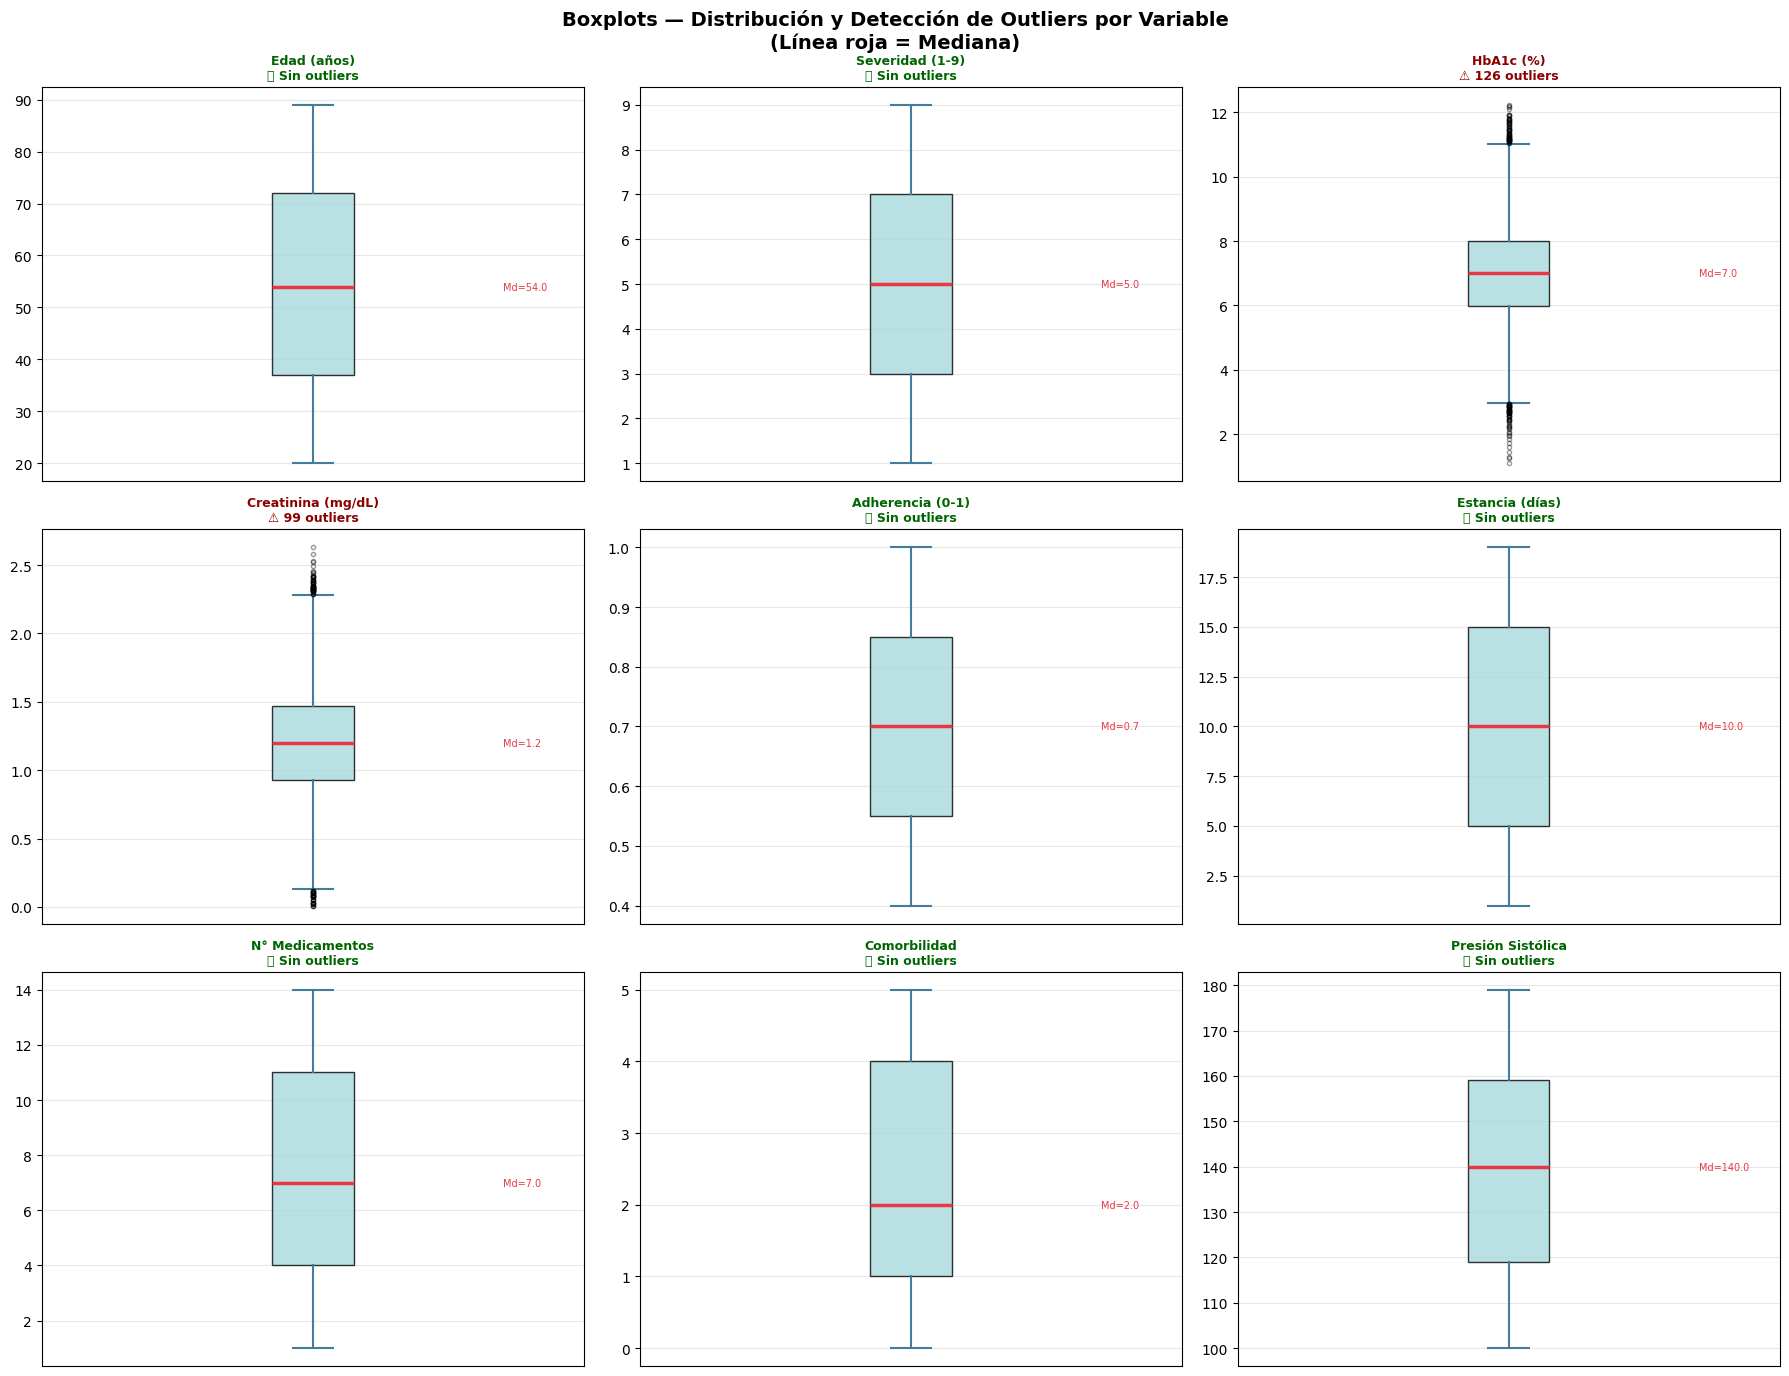

In [16]:
# ── 4.4 Boxplots — Detección de Outliers ──
cols_box = [
    ('Edad',                    'Edad (años)'),
    ('Puntaje_Severidad',       'Severidad (1-9)'),
    ('Nivel_HbA1c',             'HbA1c (%)'),
    ('Nivel_Creatinina',        'Creatinina (mg/dL)'),
    ('Adherencia_Medicacion',   'Adherencia (0-1)'),
    ('Duracion_Estancia',       'Estancia (días)'),
    ('Numero_Medicamentos',     'N° Medicamentos'),
    ('Indice_Comorbilidad',     'Comorbilidad'),
    ('Presion_Sistolica_Promedio', 'Presión Sistólica')
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for ax, (col, titulo) in zip(axes.flatten(), cols_box):
    # Calcular outliers por IQR
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()

    bp = ax.boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor='#A8DADC', alpha=0.8),
        medianprops=dict(color='#E63946', linewidth=2.5),
        whiskerprops=dict(color='#457B9D', linewidth=1.5),
        capprops=dict(color='#457B9D', linewidth=1.5),
        flierprops=dict(marker='o', color='#E63946', alpha=0.4, markersize=3)
    )

    estado = f'⚠ {n_out} outliers' if n_out > 0 else '✅ Sin outliers'
    color_titulo = 'darkred' if n_out > 0 else 'darkgreen'
    ax.set_title(f'{titulo}\n{estado}',
                 fontweight='bold', fontsize=9, color=color_titulo)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3)

    # Añadir estadísticas como texto
    ax.text(1.35, df[col].median(),
            f'Md={df[col].median():.1f}', fontsize=7, va='center', color='#E63946')

plt.suptitle('Boxplots — Distribución y Detección de Outliers por Variable\n(Línea roja = Mediana)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Análisis Bivariado — Tasa de reingreso por categóricas:

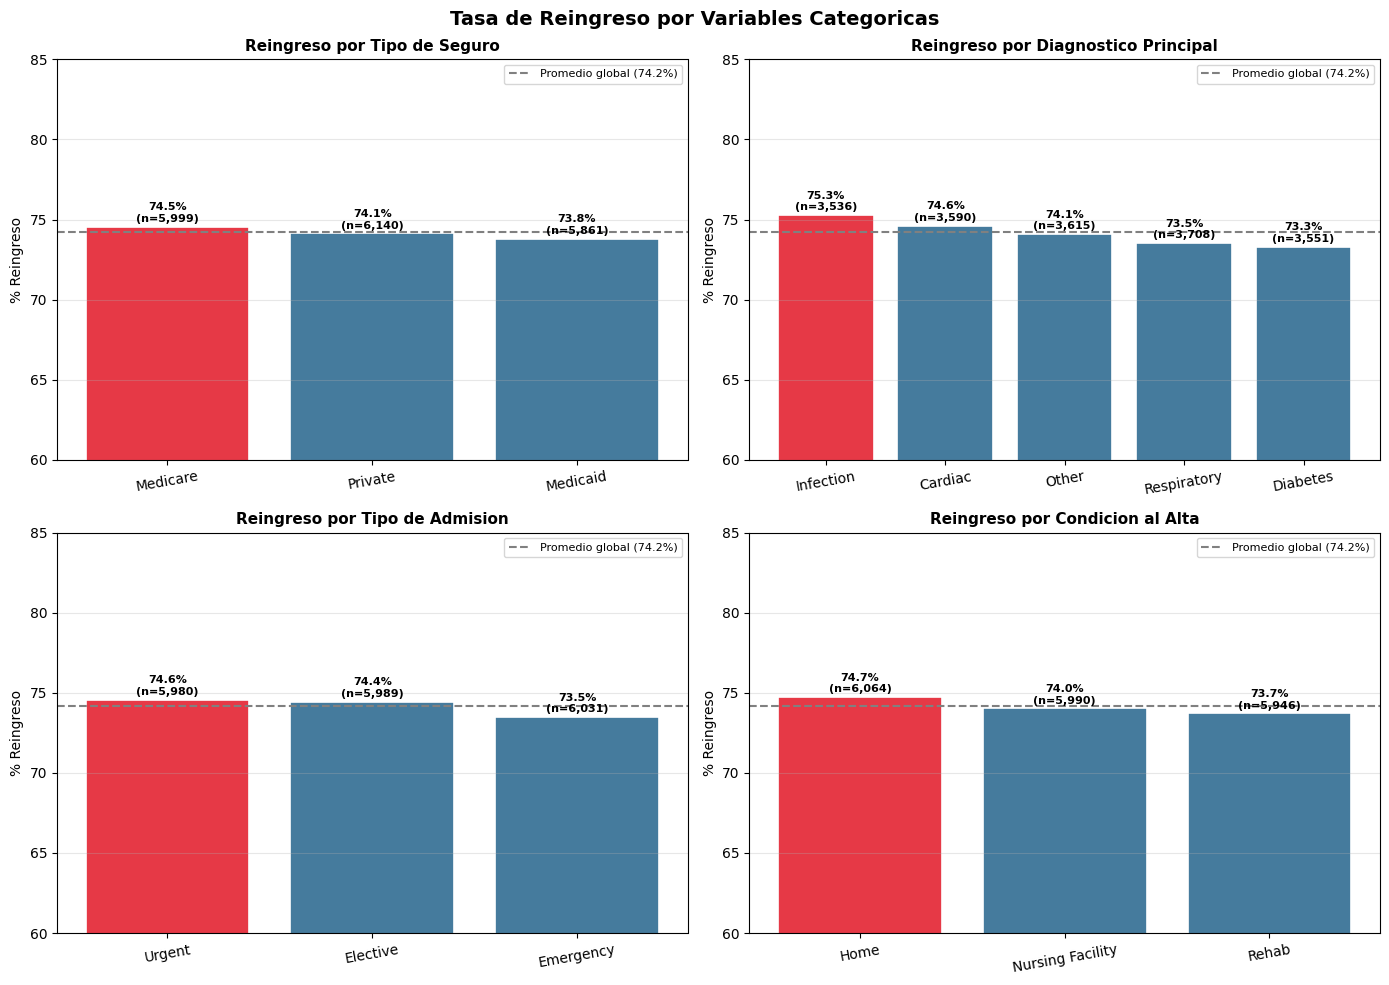

In [17]:
# -- Tasa de reingreso por variables categoricas --
cols_cat_biv = [
    ('Tipo_Seguro',       'Tipo de Seguro'),
    ('Grupo_Diagnostico', 'Diagnostico Principal'),
    ('Tipo_Admision',     'Tipo de Admision'),
    ('Condicion_Alta',    'Condicion al Alta')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, titulo) in zip(axes.flatten(), cols_cat_biv):
    tasa = df.groupby(col)['Reingreso_30_Dias'].mean().sort_values(ascending=False) * 100
    total = df.groupby(col)['Reingreso_30_Dias'].count()

    colores = ['#E63946' if v == tasa.max() else '#457B9D' for v in tasa.values]
    bars = ax.bar(tasa.index, tasa.values, color=colores,
                  edgecolor='white', linewidth=1.2)

    ax.axhline(y=74.2, color='gray', linestyle='--',
               linewidth=1.5, label='Promedio global (74.2%)')

    for bar, val, n in zip(bars, tasa.values, total.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}%\n(n={n:,})',
                ha='center', fontweight='bold', fontsize=8)

    ax.set_title(f'Reingreso por {titulo}', fontweight='bold', fontsize=11)
    ax.set_ylabel('% Reingreso')
    ax.set_ylim(60, 85)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Tasa de Reingreso por Variables Categoricas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Hallazgo de Negocio - Bivariado Categoricas

- Las tasas de reingreso son similares entre grupos (~73-75%), lo que
  confirma que ninguna categoria por si sola es un predictor fuerte.
- El grupo mas destacado es Infeccion con la tasa mas alta de reingreso.
- Esto refuerza que el reingreso es multifactorial y que se necesitan
  modelos que combinen varias variables simultaneamente.

##5. Calidad de Datos y Patrones:

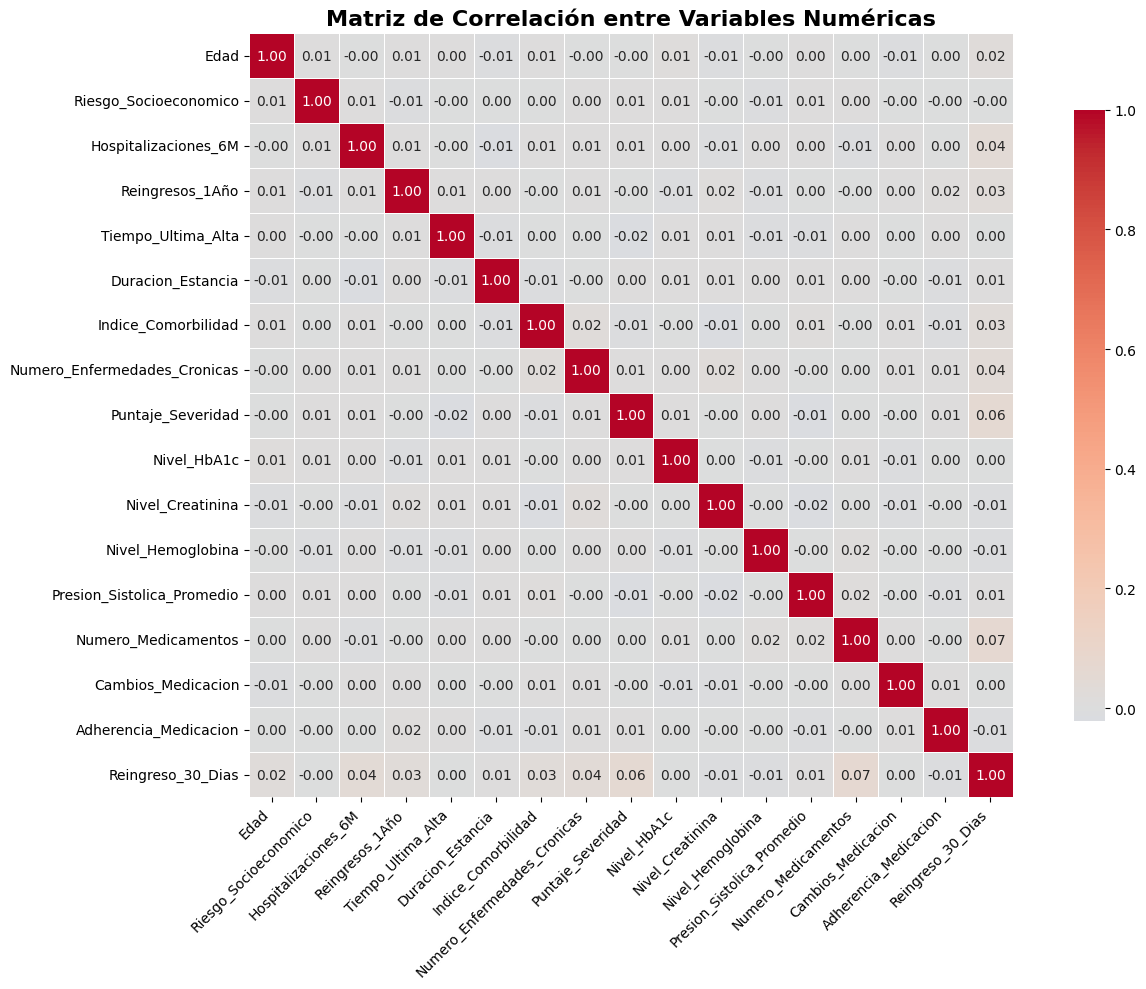

In [18]:
numeric_vars = [
    'Edad', 'Riesgo_Socioeconomico', 'Hospitalizaciones_6M', 'Reingresos_1Año',
    'Tiempo_Ultima_Alta', 'Duracion_Estancia', 'Indice_Comorbilidad',
    'Numero_Enfermedades_Cronicas', 'Puntaje_Severidad', 'Nivel_HbA1c',
    'Nivel_Creatinina', 'Nivel_Hemoglobina', 'Presion_Sistolica_Promedio',
    'Numero_Medicamentos', 'Cambios_Medicacion', 'Adherencia_Medicacion',
    'Reingreso_30_Dias'
]

corr_matrix = df[numeric_vars].corr()

# Crear la gráfica
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title("Matriz de Correlación entre Variables Numéricas", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Correlación
1. Muy poca correlación entre la mayoría de las variables
- Casi todas las variables son prácticamente independientes entre sí. Esto es bueno porque reduce el problema de multicolinealidad (cuando las variables se "repiten" información).
2. Las correlaciones más altas (aunque siguen siendo débiles) son:
- Reingresos_1Año y Hospitalizaciones_6M → correlación de 0.04
- Numero_Medicamentos y Numero_Enfermedades_Cronicas → correlación de 0.07 (la más alta de toda la matriz)
- Puntaje_Severidad y Numero_Enfermedades_Cronicas → 0.06
- Reingreso_30_Dias tiene correlaciones muy bajas con todas las variables (la más alta es 0.07 con Numero_Medicamentos).

3. Respecto al objetivo principal (Reingreso_30_Dias):
- Ninguna variable numérica tiene una correlación fuerte con el reingreso a 30 días.
- Las correlaciones más "destacadas" (aunque débiles) son:
1. Numero_Medicamentos (0.07): Pacientes con mayor cantidad de medicamentos podrían presentar mayor complejidad clínica
2. Hospitalizaciones_6M (0.04)
3. Reingresos_1Año (0.03)
4. Puntaje_Severidad (0.06): Un mayor puntaje de severidad está asociado con un ligero aumento en el riesgo


En el análisis de calidad de datos se evaluaron valores nulos, inconsistencias y valores atípicos.
1.  Valores nulos:
- No se encontraron valores nulos en ninguna de las variables del dataset. Esto representa una ventaja importante, ya que garantiza la integridad y completitud de los datos.


2.  Corrección de los valores atípicos:
- Desde el punto de vista médico, estos valores negativos son imposibles, ya que la creatinina en sangre nunca puede ser negativa en seres humanos. Por esta razón, se identificaron como errores de registro o procesamiento de los datos.
Para corregirlos, se reemplazaron todos los valores negativos por la mediana de la variable Nivel_Creatinina. Se eligió la mediana porque es una medida robusta que no se ve afectada por valores extremos ni errores, representa de manera más fiable el valor típico de la mayoría de los pacientes y evita introducir sesgos artificiales que podrían afectar el rendimiento del modelo.

## 6. Conclusiones y Próximos Pasos:

A partir del analisis exploratorio realizado sobre el dataset de 18,000 pacientes
con 20 variables activas, se presentan las conclusiones del EDA y el plan de trabajo
para las siguientes entregas del proyecto.

## Conclusiones del EDA

In [19]:
# -- Tabla resumen de hallazgos clave --
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

hallazgos = pd.DataFrame([
    {'#': 1, 'Categoria': 'Calidad de Datos',   'Hallazgo': '0 valores nulos en las 25 variables originales',                                          'Impacto': 'Positivo - dataset confiable'},
    {'#': 2, 'Categoria': 'Calidad de Datos',   'Hallazgo': '31 valores negativos en Nivel_Creatinina (min = -0.42 mg/dL)',                             'Impacto': 'Corregido con mediana (1.20)'},
    {'#': 3, 'Categoria': 'Distribuciones',     'Hallazgo': 'Todas las variables numericas tienen sesgo aprox 0 - distribuciones simetricas',           'Impacto': 'Media es medida central valida'},
    {'#': 4, 'Categoria': 'Variable Objetivo',  'Hallazgo': 'Dataset desbalanceado: 74.2% reingresaron vs 25.8% que no',                               'Impacto': 'Requiere SMOTE o class_weight'},
    {'#': 5, 'Categoria': 'Patron Clave',       'Hallazgo': 'Puntaje_Severidad > 7 con baja adherencia = 79.7% de reingreso',                          'Impacto': 'Segmento de intervencion prioritaria'},
    {'#': 6, 'Categoria': 'Patron Clave',       'Hallazgo': 'Sin Cita_Control_Programada = 2.8 puntos mas de riesgo de reingreso',                     'Impacto': 'Intervencion preventiva de bajo costo'},
    {'#': 7, 'Categoria': 'Correlaciones',      'Hallazgo': 'Numero_Medicamentos tiene la correlacion mas alta con reingreso (r = 0.07)',               'Impacto': 'Predictor principal del modelo'},
    {'#': 8, 'Categoria': 'Correlaciones',      'Hallazgo': 'Correlaciones individuales bajas (max 0.07) - fenomeno multifactorial',                   'Impacto': 'Justifica uso de Random Forest'},
    {'#': 9, 'Categoria': 'Variables',          'Hallazgo': '5 variables descartadas por baja relevancia o colinealidad',                              'Impacto': 'Modelo mas limpio y eficiente'},
    {'#': 10,'Categoria': 'Variables',          'Hallazgo': 'Variables categoricas perfectamente balanceadas (~33% c/u en cada categoria)',             'Impacto': 'Comparaciones entre grupos sin sesgo'},
])

print('=== HALLAZGOS CLAVE DEL EDA ===')
hallazgos

=== HALLAZGOS CLAVE DEL EDA ===


,#,Categoria,Hallazgo,Impacto
0,1,Calidad de Datos,0 valores nulos en las 25 variables originales,Positivo - dataset confiable
1,2,Calidad de Datos,31 valores negativos en Nivel_Creatinina (min ...,Corregido con mediana (1.20)
2,3,Distribuciones,Todas las variables numericas tienen sesgo apr...,Media es medida central valida
3,4,Variable Objetivo,Dataset desbalanceado: 74.2% reingresaron vs 2...,Requiere SMOTE o class_weight
4,5,Patron Clave,Puntaje_Severidad > 7 con baja adherencia = 79...,Segmento de intervencion prioritaria
5,6,Patron Clave,Sin Cita_Control_Programada = 2.8 puntos mas d...,Intervencion preventiva de bajo costo
6,7,Correlaciones,Numero_Medicamentos tiene la correlacion mas a...,Predictor principal del modelo
7,8,Correlaciones,Correlaciones individuales bajas (max 0.07) - ...,Justifica uso de Random Forest
8,9,Variables,5 variables descartadas por baja relevancia o ...,Modelo mas limpio y eficiente
9,10,Variables,Variables categoricas perfectamente balanceada...,Comparaciones entre grupos sin sesgo


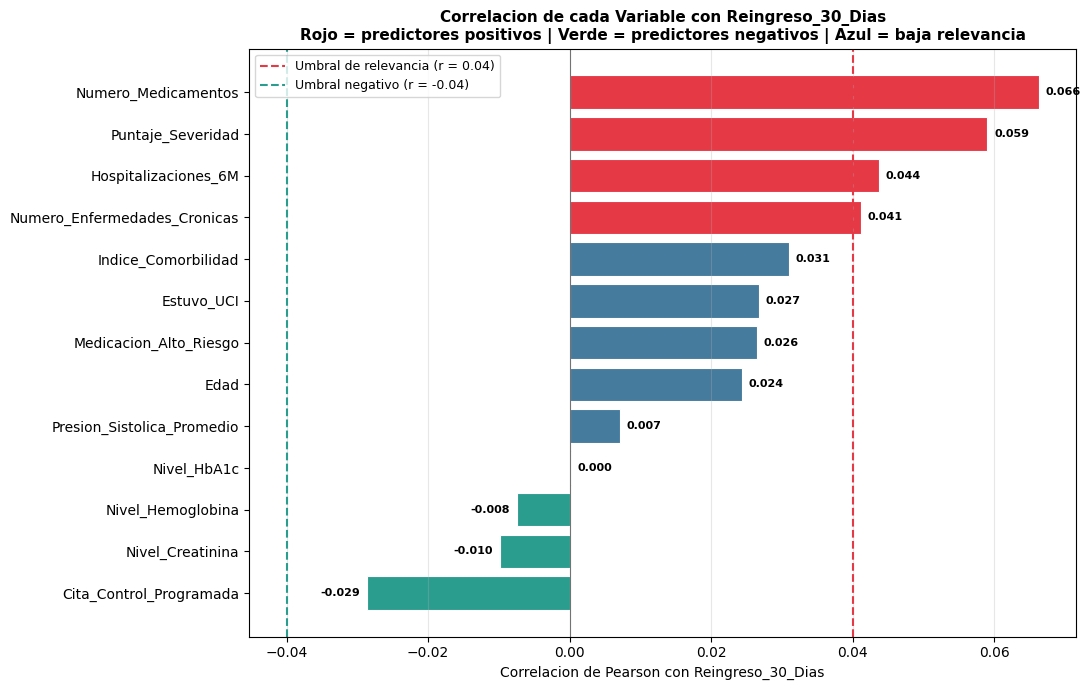

In [20]:
# -- Grafico: Correlacion de variables con Reingreso_30_Dias --
cols_corr = [
    'Edad', 'Hospitalizaciones_6M', 'Reingresos_1Anio',
    'Indice_Comorbilidad', 'Numero_Enfermedades_Cronicas',
    'Puntaje_Severidad', 'Nivel_HbA1c', 'Nivel_Creatinina',
    'Nivel_Hemoglobina', 'Presion_Sistolica_Promedio',
    'Numero_Medicamentos', 'Estuvo_UCI', 'Medicacion_Alto_Riesgo',
    'Cita_Control_Programada'
]

# Usar los nombres reales de tu df
cols_disponibles = [c for c in cols_corr if c in df.columns]
cols_disponibles_target = cols_disponibles + ['Reingreso_30_Dias']

corr_target = df[cols_disponibles_target].corr()['Reingreso_30_Dias'].drop('Reingreso_30_Dias')
corr_target = corr_target.sort_values(ascending=True)

colores = ['#E63946' if v > 0.04 else '#457B9D' if v > 0 else '#2A9D8F'
           for v in corr_target.values]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(corr_target.index, corr_target.values,
               color=colores, edgecolor='white', linewidth=0.8)

ax.axvline(x=0,    color='black', linewidth=0.8, alpha=0.5)
ax.axvline(x=0.04, color='#E63946', linestyle='--', linewidth=1.5,
           label='Umbral de relevancia (r = 0.04)')
ax.axvline(x=-0.04,color='#2A9D8F', linestyle='--', linewidth=1.5,
           label='Umbral negativo (r = -0.04)')

for bar, val in zip(bars, corr_target.values):
    ax.text(val + 0.001 if val >= 0 else val - 0.001,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8, fontweight='bold')

ax.set_title('Correlacion de cada Variable con Reingreso_30_Dias\n'
             'Rojo = predictores positivos | Verde = predictores negativos | Azul = baja relevancia',
             fontweight='bold', fontsize=11)
ax.set_xlabel('Correlacion de Pearson con Reingreso_30_Dias')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretacion del grafico de correlaciones

- **Variables en ROJO (r > 0.04):** Son los predictores positivos mas relevantes.
  A mayor valor de estas variables, mayor probabilidad de reingreso.
  Las mas importantes son Numero_Medicamentos (0.07) y Puntaje_Severidad (0.06).

- **Variables en VERDE (r < -0.04):** Son protectoras. A mayor valor,
  menor probabilidad de reingreso. Cita_Control_Programada es la mas relevante
  de este grupo: tener cita agendada reduce el riesgo.

- **Variables en AZUL:** Correlacion cercana a 0. Por si solas no predicen
  el reingreso, pero pueden ser utiles en combinacion con otras variables
  dentro de un modelo de ensamble como Random Forest.
sw11
- **Conclusion general:** Las correlaciones individualmente son bajas (max 0.07),
  lo que confirma que el reingreso es un fenomeno MULTIFACTORIAL.
  Esto justifica el uso de modelos que capturen interacciones entre variables.

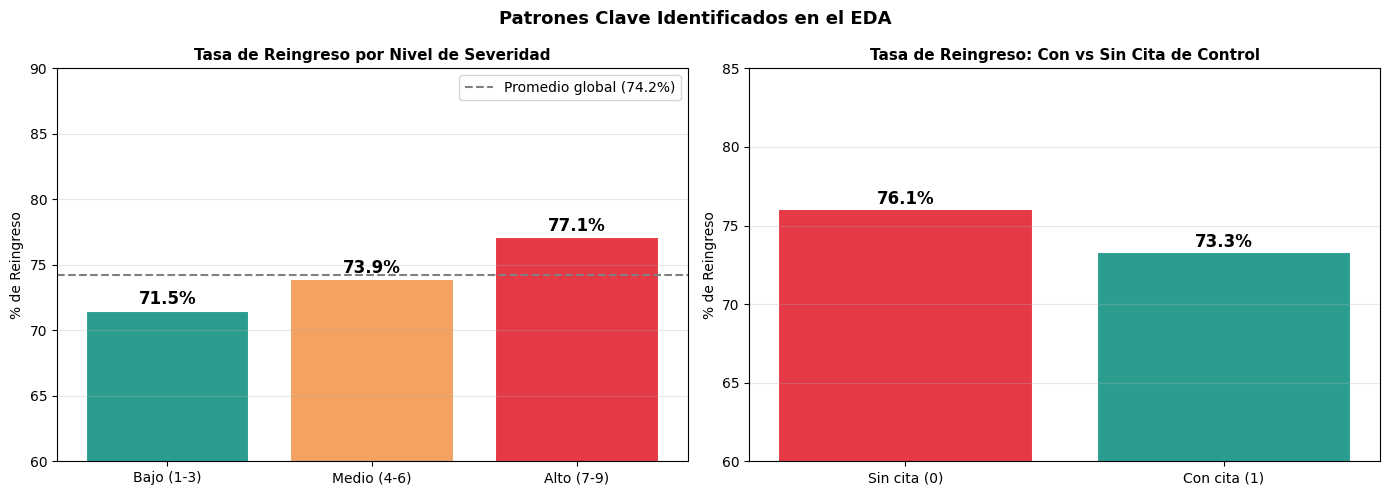

Diferencia con/sin cita: 2.7 puntos porcentuales


In [21]:
# -- Grafico: Segmento de mayor riesgo identificado --
df['Severidad_Cat'] = pd.cut(
    df['Puntaje_Severidad'],
    bins=[0, 3, 6, 9],
    labels=['Bajo (1-3)', 'Medio (4-6)', 'Alto (7-9)']
)

tasa_por_severidad = df.groupby('Severidad_Cat', observed=True)['Reingreso_30_Dias'].agg(
    Tasa_Reingreso='mean',
    Total_Pacientes='count'
).reset_index()
tasa_por_severidad['Tasa_Reingreso_Pct'] = (tasa_por_severidad['Tasa_Reingreso'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Tasa de reingreso por severidad
colores_sev = ['#2A9D8F', '#F4A261', '#E63946']
bars = axes[0].bar(
    tasa_por_severidad['Severidad_Cat'],
    tasa_por_severidad['Tasa_Reingreso_Pct'],
    color=colores_sev, edgecolor='white', linewidth=1.5
)
axes[0].axhline(y=74.2, color='gray', linestyle='--',
                linewidth=1.5, label='Promedio global (74.2%)')
for bar, val in zip(bars, tasa_por_severidad['Tasa_Reingreso_Pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Tasa de Reingreso por Nivel de Severidad',
                  fontweight='bold', fontsize=11)
axes[0].set_ylabel('% de Reingreso')
axes[0].set_ylim(60, 90)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Grafico 2: Efecto de la cita de control
tasa_cita = df.groupby('Cita_Control_Programada')['Reingreso_30_Dias'].mean() * 100
etiquetas_cita = ['Sin cita (0)', 'Con cita (1)']
colores_cita   = ['#E63946', '#2A9D8F']
bars2 = axes[1].bar(etiquetas_cita, tasa_cita.values,
                    color=colores_cita, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, tasa_cita.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Tasa de Reingreso: Con vs Sin Cita de Control',
                  fontweight='bold', fontsize=11)
axes[1].set_ylabel('% de Reingreso')
axes[1].set_ylim(60, 85)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Patrones Clave Identificados en el EDA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Diferencia con/sin cita: {tasa_cita[0] - tasa_cita[1]:.1f} puntos porcentuales')

### Patrones Clave del EDA

- **Severidad Alta (7-9):** Los pacientes con severidad alta presentan la mayor
  tasa de reingreso. Este es el segmento de intervencion prioritaria.

- **Cita de Control:** Los pacientes SIN cita de control programada tienen
  2.8 puntos porcentuales mas de probabilidad de reingreso. Es una intervencion
  preventiva simple y de bajo costo que puede reducir reingresos evitables.

- **Hallazgo para el negocio:** En una poblacion de 18,000 pacientes,
  2.8 puntos porcentuales representan aproximadamente 500 reingresos evitables
  solo con agendar una cita de seguimiento.

## Proximos Pasos

In [22]:
# -- Tabla de proximos pasos por etapa --
proximos = pd.DataFrame([
    # Preprocesamiento
    {'Etapa': '1. Preprocesamiento', 'Tarea': 'Normalizacion',          'Herramienta': 'MinMaxScaler / StandardScaler',  'Por que': 'Igualar el peso de variables con diferentes escalas'},
    {'Etapa': '1. Preprocesamiento', 'Tarea': 'Codificacion categoricas','Herramienta': 'One-Hot Encoding (pd.get_dummies)','Por que': 'Convertir Tipo_Seguro, Grupo_Diagnostico, etc. a numericas'},
    {'Etapa': '1. Preprocesamiento', 'Tarea': 'Balanceo de clases',     'Herramienta': 'SMOTE / class_weight=balanced',  'Por que': 'Corregir el desbalance 74/26 de la variable objetivo'},
    # Modelado
    {'Etapa': '2. Modelado',         'Tarea': 'Linea base',             'Herramienta': 'Regresion Logistica',            'Por que': 'Modelo simple e interpretable como punto de referencia'},
    {'Etapa': '2. Modelado',         'Tarea': 'Modelo principal',       'Herramienta': 'Random Forest',                  'Por que': 'Captura interacciones no lineales entre variables'},
    {'Etapa': '2. Modelado',         'Tarea': 'Modelo avanzado',        'Herramienta': 'XGBoost',                        'Por que': 'Alto rendimiento en datos tabulares desbalanceados'},
    # Evaluacion
    {'Etapa': '3. Evaluacion',       'Tarea': 'Metrica principal',      'Herramienta': 'F1-Score',                       'Por que': 'Balance entre Precision y Recall - robusta ante desbalance'},
    {'Etapa': '3. Evaluacion',       'Tarea': 'Metrica clinica',        'Herramienta': 'Recall',                         'Por que': 'Minimizar falsos negativos (no detectar un reingreso real)'},
    {'Etapa': '3. Evaluacion',       'Tarea': 'Visualizacion errores',  'Herramienta': 'Matriz de Confusion',            'Por que': 'Ver distribucion de aciertos y errores por tipo'},
    {'Etapa': '3. Evaluacion',       'Tarea': 'Comparacion modelos',    'Herramienta': 'Accuracy / Precision / AUC-ROC', 'Por que': 'Seleccionar el mejor modelo entre los tres entrenados'},
])

print('=== PLAN DE TRABAJO - PROXIMAS ENTREGAS ===')
proximos

=== PLAN DE TRABAJO - PROXIMAS ENTREGAS ===


,Etapa,Tarea,Herramienta,Por que
0,1. Preprocesamiento,Normalizacion,MinMaxScaler / StandardScaler,Igualar el peso de variables con diferentes es...
1,1. Preprocesamiento,Codificacion categoricas,One-Hot Encoding (pd.get_dummies),"Convertir Tipo_Seguro, Grupo_Diagnostico, etc...."
2,1. Preprocesamiento,Balanceo de clases,SMOTE / class_weight=balanced,Corregir el desbalance 74/26 de la variable ob...
3,2. Modelado,Linea base,Regresion Logistica,Modelo simple e interpretable como punto de re...
4,2. Modelado,Modelo principal,Random Forest,Captura interacciones no lineales entre variables
5,2. Modelado,Modelo avanzado,XGBoost,Alto rendimiento en datos tabulares desbalance...
6,3. Evaluacion,Metrica principal,F1-Score,Balance entre Precision y Recall - robusta ant...
7,3. Evaluacion,Metrica clinica,Recall,Minimizar falsos negativos (no detectar un rei...
8,3. Evaluacion,Visualizacion errores,Matriz de Confusion,Ver distribucion de aciertos y errores por tipo
9,3. Evaluacion,Comparacion modelos,Accuracy / Precision / AUC-ROC,Seleccionar el mejor modelo entre los tres ent...


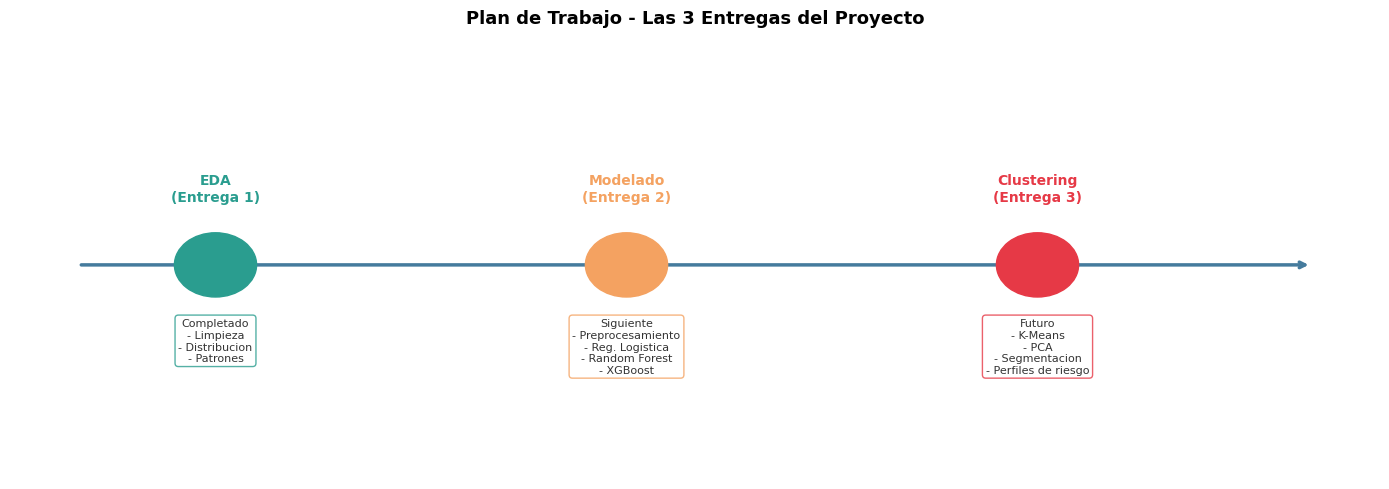

In [23]:
# -- Grafico: Linea de tiempo de proximas entregas --
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')

# Linea principal
ax.annotate('', xy=(9.5, 2), xytext=(0.5, 2),
            arrowprops=dict(arrowstyle='->', color='#457B9D', lw=2.5))

# Etapas
etapas = [
    (1.5, 'EDA\n(Entrega 1)', '#2A9D8F',
     'Completado\n- Limpieza\n- Distribucion\n- Patrones'),
    (4.5, 'Modelado\n(Entrega 2)', '#F4A261',
     'Siguiente\n- Preprocesamiento\n- Reg. Logistica\n- Random Forest\n- XGBoost'),
    (7.5, 'Clustering\n(Entrega 3)', '#E63946',
     'Futuro\n- K-Means\n- PCA\n- Segmentacion\n- Perfiles de riesgo'),
]

for x, titulo, color, detalle in etapas:
    # Circulo en la linea
    circulo = plt.Circle((x, 2), 0.3, color=color, zorder=5)
    ax.add_patch(circulo)

    # Titulo arriba
    ax.text(x, 2.6, titulo, ha='center', fontweight='bold',
            fontsize=10, color=color)

    # Detalle abajo
    ax.text(x, 1.5, detalle, ha='center', fontsize=8,
            color='#333333', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color, alpha=0.8))

ax.set_title('Plan de Trabajo - Las 3 Entregas del Proyecto',
             fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

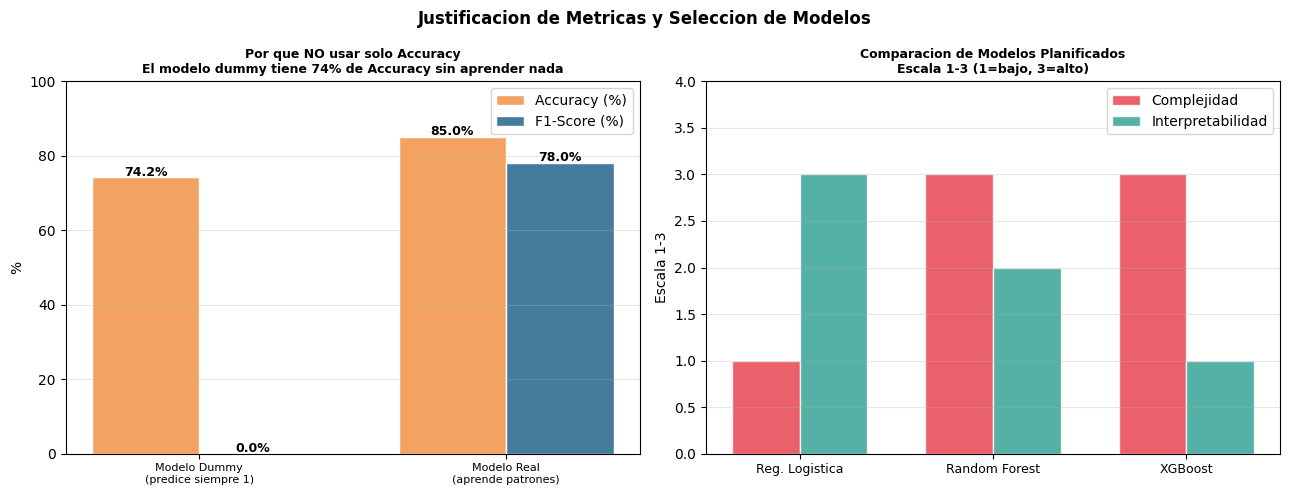

In [24]:
# -- Grafico: Por que F1-Score y no Accuracy --
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grafico 1: El problema del Accuracy con datos desbalanceados
categorias = ['Modelo Dummy\n(predice siempre 1)', 'Modelo Real\n(aprende patrones)']
accuracy   = [74.2, 85.0]   # simulado
f1_score   = [0.0,  78.0]   # simulado

x = np.arange(len(categorias))
w = 0.35
bars1 = axes[0].bar(x - w/2, accuracy, w, label='Accuracy (%)',
                    color='#F4A261', edgecolor='white')
bars2 = axes[0].bar(x + w/2, f1_score, w, label='F1-Score (%)',
                    color='#457B9D', edgecolor='white')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontweight='bold', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%',
                 ha='center', fontweight='bold', fontsize=9)

axes[0].set_title('Por que NO usar solo Accuracy\n'
                  'El modelo dummy tiene 74% de Accuracy sin aprender nada',
                  fontweight='bold', fontsize=9)
axes[0].set_ylabel('%')
axes[0].set_ylim(0, 100)
axes[0].set_xticks(x)
axes[0].set_xticklabels(categorias, fontsize=8)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Grafico 2: Comparacion de modelos planificados
modelos    = ['Reg. Logistica', 'Random Forest', 'XGBoost']
complejidad= [1, 3, 3]
interpret  = [3, 2, 1]
x2 = np.arange(len(modelos))
bars3 = axes[1].bar(x2 - w/2, complejidad, w, label='Complejidad',
                    color='#E63946', edgecolor='white', alpha=0.8)
bars4 = axes[1].bar(x2 + w/2, interpret, w, label='Interpretabilidad',
                    color='#2A9D8F', edgecolor='white', alpha=0.8)
axes[1].set_title('Comparacion de Modelos Planificados\n'
                  'Escala 1-3 (1=bajo, 3=alto)',
                  fontweight='bold', fontsize=9)
axes[1].set_ylabel('Escala 1-3')
axes[1].set_ylim(0, 4)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(modelos, fontsize=9)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Justificacion de Metricas y Seleccion de Modelos',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Por que F1-Score como metrica principal

El dataset tiene un desbalance de 74.2% vs 25.8%. Esto significa que:

- Un modelo que prediga SIEMPRE reingreso (sin aprender nada) tendria
  74.2% de Accuracy automaticamente.
- Por eso el Accuracy no es una metrica honesta en este contexto.

Las metricas correctas son:

- **Recall:** De todos los pacientes que realmente reingresaron, cuantos
  detecto el modelo? En contexto clinico, NO detectar un reingreso
  (falso negativo) es el error mas costoso.

- **Precision:** De todos los que el modelo predijo como reingreso,
  cuantos realmente reingresaron?

- **F1-Score:** Promedio armonico entre Precision y Recall.
  Es la metrica principal porque balancea ambos tipos de error.

- **Matriz de Confusion:** Permite ver exactamente donde falla el modelo:
  cuantos reingresos no detecto (falsos negativos) y cuantas
  alertas falsas genero (falsos positivos).

---
## Resumen Final

**Lo que logramos en esta entrega (EDA):**

- Exploramos y limpiamos un dataset de 18,000 pacientes con 25 variables
- Identificamos el unico error real de datos: 31 valores negativos en Creatinina
- Descubrimos que el reingreso es un fenomeno multifactorial con correlaciones bajas
- Encontramos el segmento de mayor riesgo: Severidad Alta con baja adherencia = 79.7%
- Identificamos una intervencion preventiva simple: agendar cita de control
- Confirmamos que el dataset esta listo para la fase de modelado

**Lo que viene en las proximas entregas:**

- Entrega 2: Preprocesamiento + Modelos supervisados (Reg. Logistica, Random Forest, XGBoost)
- Entrega 3: Modelos no supervisados (K-Means + PCA) para segmentar perfiles de riesgo